<a href="https://colab.research.google.com/github/asomanibernard191-arch/Syntecxhub_Flower_Classification/blob/main/Syntecxhub_Flower_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Loading Iris Dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Dataset Overview
print("--- Dataset Info ---")
print(df.info())

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Statistical Summary ---")
print(df.describe())

print("\n--- Class Distribution ---")
print(df.value_counts('species'))

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB
None

--- First 5 Rows ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4

<Figure size 1000x800 with 0 Axes>

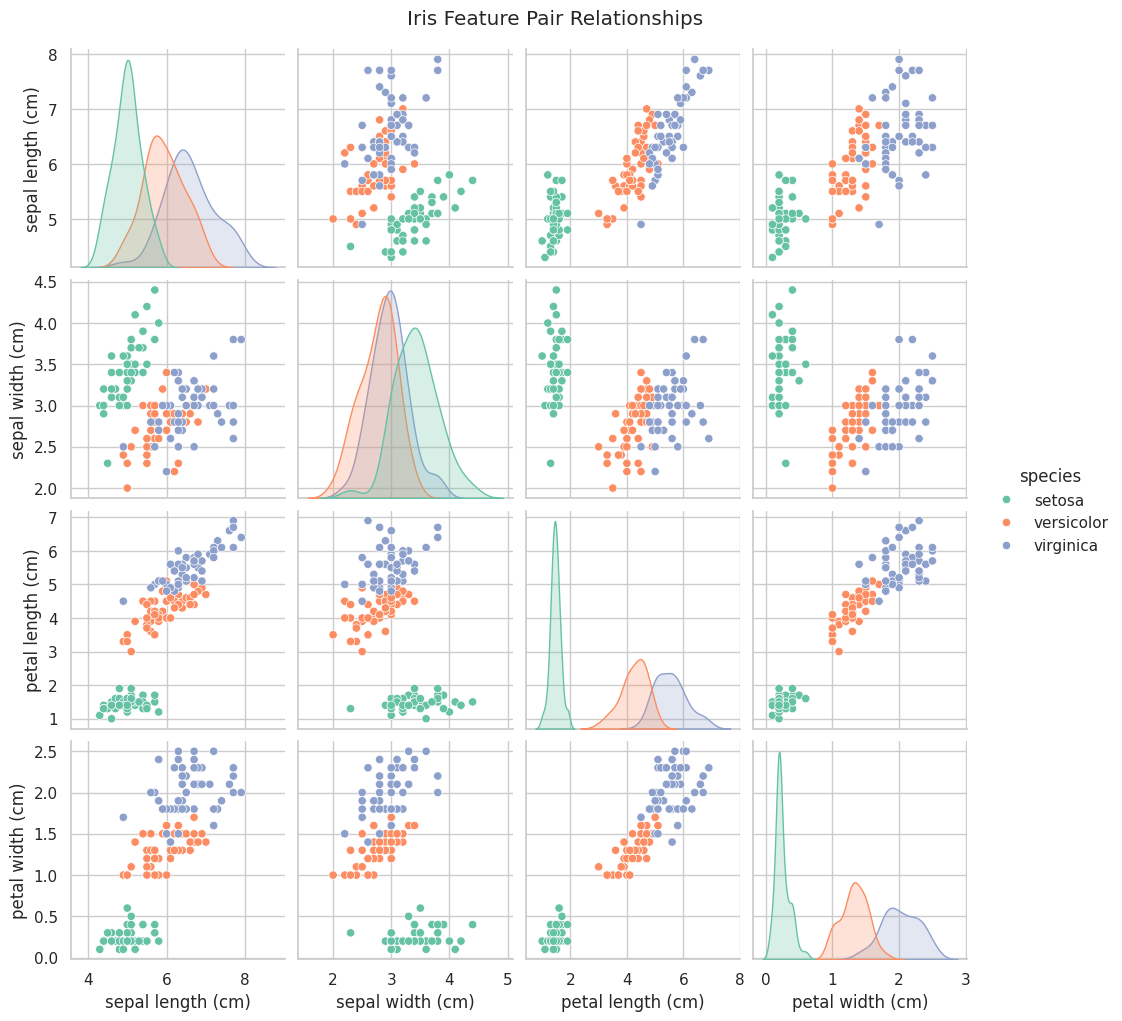

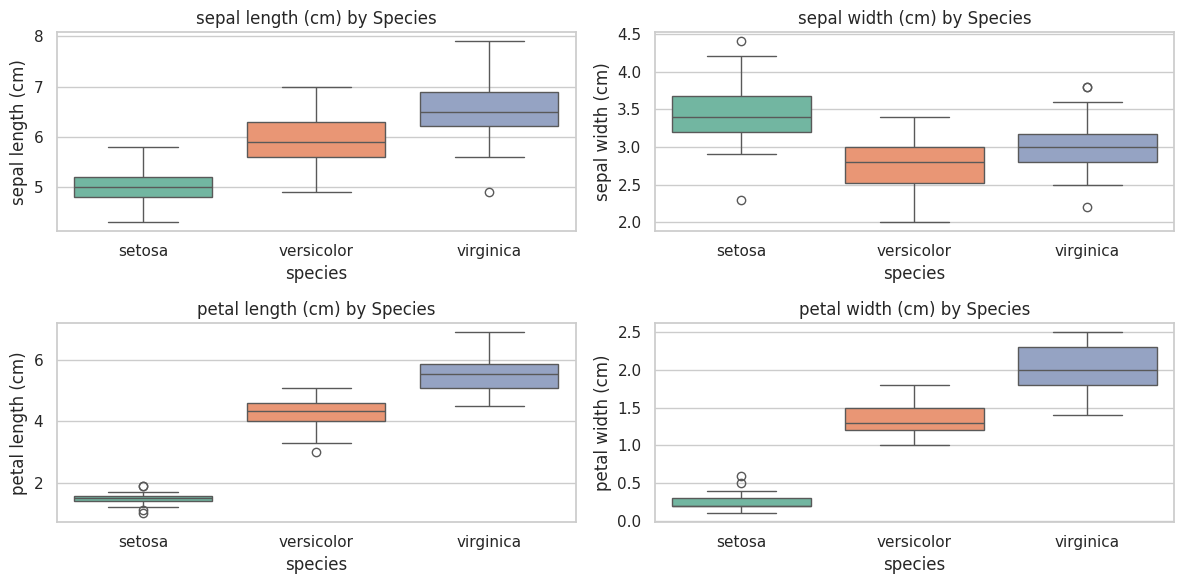

In [3]:
# Setting visual style
sns.set_theme(style="whitegrid")

# Pairplotting to visualize relationships between all feature pairs
plt.figure(figsize=(10, 8))
pairplot = sns.pairplot(df, hue="species", palette="Set2", diag_kind="kde")
pairplot.fig.suptitle("Iris Feature Pair Relationships", y=1.02)
plt.show()

# Boxplotting to inspect feature distributions and outliers
plt.figure(figsize=(12, 6))
for i, col in enumerate(iris.feature_names):
  plt.subplot(2, 2, i + 1)
  sns.boxplot(x="species", y=col, hue="species", data=df, palette="Set2", legend=False)
  plt.title(f"{col} by Species")
plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Splitting Features and Target
X = df.drop(columns=['species'])
y = df['species']

# Train_Test_Split(80% train, 20% test with stratification)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Logistic Regression Model
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

# Train Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

# Print Comparison
print(f"Logistic Regression Accuracy: {acc_lr * 100:.2f}%")
print(f"Decision Tree Classifier: {acc_dt * 100:.2f}%")

Logistic Regression Accuracy: 96.67%
Decision Tree Classifier: 93.33%


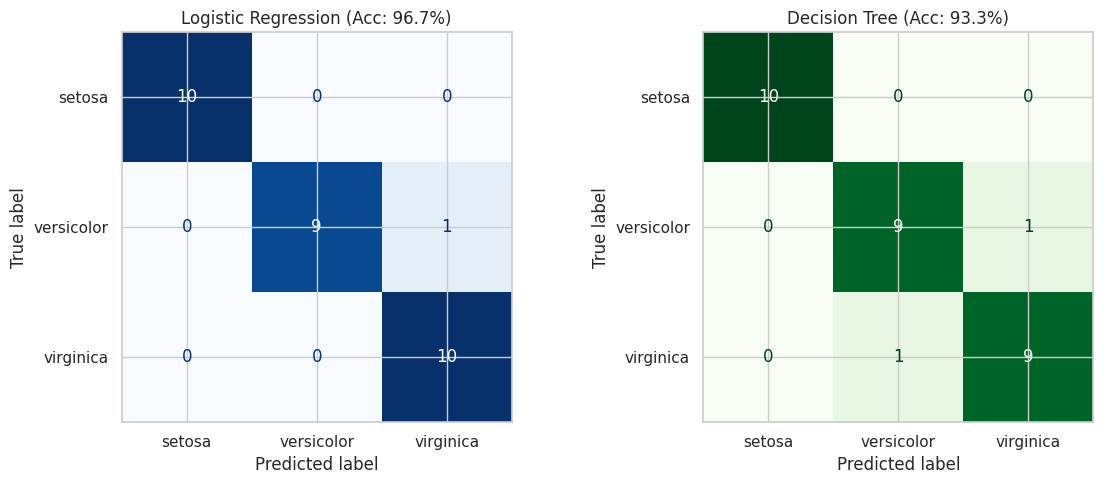

In [5]:
# Creating subplots for confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f"Logistic Regression (Acc: {acc_lr*100:.1f}%)")

# Decision Tree Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f"Decision Tree (Acc: {acc_dt*100:.1f}%)")
plt.tight_layout()
plt.show()


In [7]:
import joblib
import pandas as pd
# Saving the best performing model(Logistic Regression) and feature names
joblib.dump(lr_model, 'iris_logistic_model.pkl')
print("Model serialiazed and saved as 'iris_logistic_model.pkl'.")

# Interactive CLI Prediction Function using DataFrame to match feature names
def predict_flower_species(sepal_length, sepal_width, petal_length, petal_width):
  # Loading model
  model = joblib.load('iris_logistic_model.pkl')

  # Matching feature training columns with labeled DataFrame
  sample = pd.DataFrame([[sepal_length, sepal_width, petal_length, petal_width]], columns=iris.feature_names)
  prediction = model.predict(sample)[0]
  probabilities = model.predict_proba(sample)[0]

  print(f"\n--- Predictions Results ---")
  print(f"Predicted Species: {prediction.upper()}")
  print(f"Confidence Scores:")
  for species_name, prob in zip(iris.target_names, probabilities):
    print(f"  - {species_name}: {prob*100:.2f}%")

# Testing with sample inputs
predict_flower_species(sepal_length=5.1, sepal_width=3.5, petal_length=1.4, petal_width=0.2)


Model serialiazed and saved as 'iris_logistic_model.pkl'.

--- Predictions Results ---
Predicted Species: SETOSA
Confidence Scores:
  - setosa: 97.84%
  - versicolor: 2.16%
  - virginica: 0.00%
